In [1]:
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.model_selection import GridSearchCV, LeaveOneOut, StratifiedKFold, cross_val_predict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTEN

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
BASE_DIR = Path('./')
IN_FILE = BASE_DIR / 'data' / 'dataset_cleaned_397.csv'
N_FOLDS = 5

In [3]:
_RANDOM_STATE = 42
_CATEGORICAL_COLS = [
    'Pfam domains', 'HGNC gene family tag', 'HGNC gene family description', 
    'Function', 'Modification', 'Protein complex', 'Target molecule',
    'Target entity', 'Product'
]

def clean_data(df):
    """Perform pre-processing and encoding on input data.

    Parameters
    ----------
    df : pandas.DataFrame
        Feature matrix with shape (n_samples, n_features).
    
    Returns
    -------
    X : ndarray of shape (n_resamples, n_encoded_features)
        Cleaned and encoded feature matrix.
    y : ndarray of shape (n_resamples)
        Class identities of resampled data.
    class_labels : list[str]
        List of class labels with index corresponding to class encoding.

    Notes
    -----
    Pre-processing comprises removing non-feature columns (protein name and symbol), 
    removing rows which have no data, and encoding class labels to a categorical variable
    taking on values from 0 to `n`-1 where `n` is the number of classes.
    """
    df = df.rename(columns={'REW (Convert to Numbers)': 'REW'})
    df = df.replace(['#', np.nan], '')

    # DROP NON-FEATURE COLUMNS
    df = df.drop(['ID (REMOVE)', 'SYMBOL', 'HGNC approved name'], axis=1)

    # REMOVE ROWS WITHOUT DATA
    to_check = df.columns[5:] # remaining cols: 'Modification' , 'Protein complex', 'Target molecule', 'Target entity', 'Product'
    df = df.dropna(how='all', subset=to_check)

    # SEPARATE FEATURES FROM LABELS
    X = df.iloc[:, 1:].astype('category')
    y_ = df.iloc[:, 0]
    le = LabelEncoder()
    y = le.fit_transform(y_)
    class_labels = list(le.classes_)

    return X, y, class_labels


def make_rew_classifier(
    clf,
    smote=True,
    onehot=True,
    var_filter__threshold=0.16,
    ft_filter__k=9,
    random_state=_RANDOM_STATE
):
    """Construct a `Pipeline` for REW classification with optional
    resampling, encoding, feature filtering, and model fitting.

    The pipeline optionally applies SMOTEN oversampling, one-hot encoding
    for categorical variables, variance thresholding, univariate feature
    selection, and a final classifier.

    Parameters
    ----------
    clf : estimator object
        A scikit-learn compatible classifier implementing `fit` and `predict`.

    smote : bool, default=True
        If True, applies SMOTEN oversampling to handle class imbalance.

    onehot : bool, default=True
        If True, applies one-hot encoding to predefined categorical columns.

    var_filter__threshold : float, default=0.16
        Features with variance below this threshold are removed via
        `VarianceThreshold`.

    ft_filter__k : int, default=9
        Number of top features to select using univariate ANOVA F-test
        (`SelectKBest` with `f_classif`).

    random_state : int or None, default=_RANDOM_STATE
        Random seed used for reproducibility in SMOTEN.

    Returns
    -------
    sklearn.pipeline.Pipeline
        A configured pipeline consisting of optional SMOTEN sampling,
        optional one-hot encoding, variance filtering, feature selection,
        and the final classifier.
    """
    steps = []

    if smote:
        steps.append(("smote", SMOTEN(random_state=random_state)))

    if onehot:
        steps.append(("onehot", ColumnTransformer(
            [("onehot", OneHotEncoder(handle_unknown="ignore"), _CATEGORICAL_COLS)],
            remainder='passthrough'
        )))

    steps += [
        ("var_filter", VarianceThreshold(threshold=var_filter__threshold)),
        ("ft_filter", SelectKBest(score_func=f_classif, k=ft_filter__k)),
        ("clf", clf)
    ]
    return Pipeline(steps)


def best_model_config(
    pipe,
    X,
    y,
    param_grid,
    cv=5,
    scoring='f1_macro'
):
    """Perform hyperparameter optimization using cross-validated grid search.

    Parameters
    ----------
    pipe : estimator object
        A scikit-learn compatible pipeline or estimator implementing `fit`
        and `predict`.

    X : array-like or pandas.DataFrame of shape (n_samples, n_features)
        Training input samples.

    y : array-like of shape (n_samples,)
        Target labels for supervised learning.

    param_grid : dict
        Dictionary or with parameter names (str) as keys and lists of 
        parameter settings to try as values.

    cv : int, cross-validation generator, or iterable, default=5
        Determines the cross-validation splitting strategy.

    scoring : str or callable, default='f1_macro'
        Metric used to evaluate model performance across folds.

    Returns
    -------
    sklearn.model_selection.GridSearchCV
        A fitted GridSearchCV object containing:
        - `cv_results_`: detailed results for all parameter combinations
        - `best_params_`: best hyperparameter setting found
        - `best_score_`: best cross-validation score
        - `best_estimator_`: refit model trained on the full dataset
    """
    grid_search = GridSearchCV(
        pipe, 
        param_grid, 
        scoring=scoring, 
        refit=True, 
        cv=cv)
    grid_search.fit(X, y)
    return grid_search

In [4]:
def loocv(model, X, y):
    """Perform Leave-One-Out Cross Validation on a dataset using a given model.
    
    Parameters
    ----------
    model : estimator
        Classifier to validate. Must implement `fit` and `predict_proba`.
    X : ndarray of shape (n_samples, n_features)
        Feature matrix to validate on.
    y : ndarray of shape (n_samples,) or (n_samples, n_classes)
        Ground truth labels to validate on.

    Returns
    -------
    acc : float
        Accuracy score.
    f1 : float
        Macro F1 score.
    auc : float
        AUC ROC.
    mcc : float
        Matthews Correlation coefficient.
    cm : ndarray of shape (n_classes, n_classes)
        Confusion matrix where the `i`th row and `j`th column is the number of 
        class `i` samples that were classified as class `j`. 
    """
    y_proba = cross_val_predict(
        model, 
        X, 
        y, 
        cv=LeaveOneOut(), 
        method="predict_proba"
    )
    y_preds = np.argmax(y_proba, axis=1)
    
    acc = accuracy_score(y, y_preds)
    f1 = f1_score(y, y_preds, average='macro')
    auc = roc_auc_score(y, y_proba, multi_class='ovr')
    cm = confusion_matrix(y, y_preds)
    mcc = matthews_corrcoef(y, y_preds)
    return acc, f1, auc, mcc, cm


def kfoldcv(model, X, y, k=5, random_state=None):
    """Perform k-fold stratified cross validation on a dataset using a given model.
    
    Parameters
    ----------
    model : estimator
        Classifier to validate. Must implement `fit` and `predict_proba`.
    X : ndarray of shape (n_samples, n_features)
        Feature matrix to validate on.
    y : ndarray of shape (n_samples,) or (n_samples, n_classes)
        Ground truth labels to validate on.
    k : int
        Number of folds for cross validation.
    random_state : int, default=`None`
        Controls the shuffling order of samples. Pass in an int for reproducible
        outputs.

    Returns
    -------
    acc : float
        Accuracy score.
    f1 : float
        Macro F1 score.
    auc : float
        AUC ROC.
    mcc : float
        Matthews Correlation coefficient.
    cm : ndarray of shape (n_classes, n_classes)
        Confusion matrix where the `i`th row and `j`th column is the number of 
        class `i` samples that were classified as class `j`. 
    """
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
    accs = []
    f1s = []
    aucs = []
    mccs = []
    cms = []

    for split, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)

        y_preds = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        accs.append(accuracy_score(y_test, y_preds))
        f1s.append(f1_score(y_test, y_preds, average="macro"))
        aucs.append(roc_auc_score(y_test, y_proba, multi_class="ovr"))
        mccs.append(matthews_corrcoef(y_test, y_preds))
        cms.append(confusion_matrix(y_test, y_preds))

    acc = np.mean(accs)
    f1 = np.mean(f1s)
    auc = np.mean(aucs)
    mcc = np.mean(mccs)
    cm = np.sum(cms, axis=0)
    return acc, f1, auc, mcc, cm

In [ ]:
def create_cm(confusion_matrix, model_name=None, class_labels=None, save_to=None):
    """Generate a heatmap visualization of a confusion matrix.
    
    Parameters
    ----------
    confusion_matrix : ndarray of shape (n_classes, n_classes)
        Square matrix where the `i`th row and `j`th column is the number of 
        class `i` samples that were classified as class `j`
    model_name : str, default=`None`
        Name of the model from which the confusion matrix. If `None` then the 
        heatmap will not have a title.
    class_labels : ndarray of shape (n_classes,), default=`None`
        Labels for each class. If `None` then the labels will either be ordinal categories 
        or the index/column information if `confusion_matrix` is a pandas.DataFrame.
    save_to : str, default=`None`
        Filepath to save heatmap image. If `None` then image will not be saved.

    Returns
    -------
    ax : matplotlib.axes.Axes
        Heatmap of confusion matrix. 
    """
    plot_params = {
        'sns_style': 'white',
        'figsize': (4,4),
        'fontscale': 1.2,
        'class_fontsize': 14,
        'title_fontsize': 14,
        'cmap':'RdPu',
    }

    sns.set_theme(
        style=plot_params['sns_style'], 
        font_scale=plot_params['fontscale']
    )
    fig, ax = plt.subplots(figsize=plot_params['figsize'])
    ax = sns.heatmap(
        confusion_matrix,
        ax=ax,
        annot=True,
        square=True,
        cmap=plot_params['cmap'], 
        fmt="d",
        cbar_kws={"shrink": 0.85}
    )
    ax.xaxis.tick_top()
    ax.yaxis.tick_left()
    if class_labels:
        ax.set_xticklabels(class_labels, fontsize=plot_params['class_fontsize'])
        ax.set_yticklabels(class_labels, fontsize=plot_params['class_fontsize'])
    if model_name:
        ax.set_xlabel(
            model_name, 
            fontsize=plot_params['title_fontsize'], 
            labelpad=11
        )
    if save_to:
        fig.savefig(
            save_to, 
            format="png", 
            bbox_inches='tight', 
            dpi=600
        )
    return ax


def create_cm_grid(df, class_labels=None, save_to=None):
    """Generate a 2x4 grid of heatmaps for multiple confusion matrices.
    
    Parameters
    ----------
    confusion_matrix : ndarray of shape (n_models, n_metrics)
        Matrix indexed by model name where the "Confusion Matrix" column of the 
        `i`th row is the confusion matrix of the `i`th model. 
    class_labels : ndarray of shape (n_classes,), default=`None`
        Labels for each class. If `None` then the labels will either be ordinal categories 
        or the index/column information if `confusion_matrix` is a pandas.DataFrame.
    save_to : str, default=`None`
        Filepath to save heatmap image. If `None` then image will not be saved.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Grid of confusion matrix heatmaps. 
    """
    plot_params = {
        'sns_style': 'white',
        'figsize': (20, 8),
        'fontscale': 1.2,
        'class_fontsize': 14,
        'subtitle_fontsize': 14,
        'subtitle_weight': 'bold',
        'vertical_space': 0.5,
        'cmap':'RdPu',
    }

    sns.set_theme(
        style=plot_params['sns_style'], 
        font_scale=plot_params['fontscale']
    )
    fig, axes = plt.subplots(2, 4, figsize=plot_params['figsize'])
    axes = axes.flatten()
    for i in range(len(df)):
        cm = df.iloc[i]["Confusion Matrix"]
        ax = axes[i]
        model_name = df.index[i]

        # plot heatmap
        sns.heatmap(
            cm,
            ax=ax,
            annot=True,
            square=True,
            cmap=plot_params['cmap'], 
            fmt="d",
            cbar_kws={"shrink": 0.85}
        )
        # format axes and spines
        ax.xaxis.tick_top()
        ax.yaxis.tick_left()
        if class_labels:
            ax.set_xticklabels(class_labels, fontsize=plot_params['class_fontsize'])
            ax.set_yticklabels(class_labels, fontsize=plot_params['class_fontsize'])
        if model_name:
            ax.set_xlabel(
                model_name, 
                fontsize=plot_params['subtitle_fontsize'], 
                fontweight=plot_params['subtitle_weight'],
                labelpad=11
            )
    fig.subplots_adjust(hspace=plot_params['vertical_space'])

    # turn off unused axes if any
    for ax in axes[len(df):]:
        ax.axis('off')

    # save file
    if save_to:
        fig.savefig(
            save_to, 
            format="png", 
            bbox_inches='tight', 
            dpi=600
        )
    return fig


def _long_df(wide_df, var_name="Metric", in_place=False):
    """Unpivot `wide_df` such that values are indexed by model and metric."""

    if not in_place:
        wide_df = wide_df.copy()

    wide_df['Model Name'] = wide_df.index
    return wide_df.loc[:, wide_df.columns != "Confusion Matrix"].melt(
        id_vars="Model Name",
        var_name=var_name,
        value_name="Value"
    )


def all_metric_bar_chart(df, ymin=0, ymax=1, title=None, save_to=None):
    """Create a grouped bar chart of model metrics.

    Parameters
    ----------
    df : pandas.DataFrame
        Wide-format DataFrame where each row corresponds to a model and
        columns correspond to evaluation metrics.
    ymin : float, optional
        Lower limit for the y-axis. Default is 0.
    ymax : float, optional
        Upper limit for the y-axis. Default is 1.
    title : str or None, optional
        Title for the plot. If None, no title is set.
    save_to : str or None, optional
        File path to save the figure as a PNG. If None, the figure is not saved.

    Returns
    -------
    matplotlib.axes.Axes
        The Matplotlib Axes object containing the bar plot.
    """
    plot_params = {
        'sns_style': 'white',
        'figsize': (10, 5),
        'subtitle_size': 14,
        'subtitle_weight': 'bold',
        'cmap': 'PuRd',
        'x_ticklabel_rotation': 40
    }
    
    with sns.axes_style(plot_params['sns_style']):
        # create barchart
        ldf = _long_df(df)
        fig, ax = plt.subplots(figsize=plot_params['figsize'])
        ax = sns.barplot(
            data=ldf, 
            x='Model Name', 
            y='Value', 
            hue='Metric', 
            palette=plot_params['cmap'])
        
        # format axes and spines
        sns.despine()
        ax.set_ylim(ymin, ymax)
        ax.set_yticks(np.linspace(ymin, ymax, 9))
        ax.yaxis.grid(True)

        for label in ax.get_xticklabels():
            label.set_rotation(plot_params['x_ticklabel_rotation'])
            label.set_ha("right")
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        
        # format legend and title
        ax.legend(
            loc='upper right',
            ncol=len(ax.get_legend_handles_labels()[1])
        )
        if title:
            ax.set_title(
                title, 
                fontsize=plot_params['subtitle_size'], 
                fontweight=plot_params['subtitle_weight'], 
                y=1.05
            )

    # save file
    if save_to:
        fig.savefig(
            save_to, 
            format="png", 
            bbox_inches='tight', 
            dpi=600
        )
    return ax


def metric_bar_chart_by_cv(
        loocv_df, 
        kfold_df, 
        metric, 
        ymin=0.8, 
        ymax=1, 
        title=None,
        save_to=None
    ):
    """
    Plot grouped bar charts of a selected metric across LOOCV and 5-Fold CV strategies.

    Parameters
    ----------
    loocv_df : pandas.DataFrame
        DataFrame containing Leave-One-Out cross-validation results.
        Must include model names as the index and metric columns.
    kfold_df : pandas.DataFrame
        DataFrame containing k-Fold cross-validation results with the
        same structure as `loocv_df`.
    metric : str
        Name of the metric column to compare between the two DataFrames.
    ymin : float, optional
        Lower limit of the y-axis. Default is 0.8.
    ymax : float, optional
        Upper limit of the y-axis. Default is 1.
    title : str or None, optional
        Title of the plot. If None, no title is added.
    save_to : str or None, optional
        File path to save the figure as a PNG. If None, the figure is not saved.

    Returns
    -------
    matplotlib.axes.Axes
        The Axes object containing the generated bar plot.
    """
    plot_params = {
        'sns_style': 'white',
        'figsize': (10, 5),
        'title_size': 18,
        'subtitle_weight': 'bold',
        'cmap': 'PuRd',
        'x_ticklabel_rotation': 40
    }
    
    df = pd.DataFrame({
        "Leave One Out": loocv_df[metric],
        "5-Fold": kfold_df[metric]
    }, index=loocv_df.index)
    ldf = _long_df(df, var_name="CV Type")

    with sns.axes_style(plot_params['sns_style']):
        fig, ax = plt.subplots(figsize=plot_params['figsize'])
        ax = sns.barplot(
            data=ldf, 
            x='Model Name', 
            y='Value', 
            hue='CV Type', 
            palette=plot_params['cmap'])
        
        # format axes and spines
        sns.despine()
        ax.set_ylim(ymin, ymax)
        ax.set_yticks(np.linspace(ymin, ymax, 9))
        ax.yaxis.grid(True)

        for label in ax.get_xticklabels():
            label.set_rotation(plot_params['x_ticklabel_rotation'])
            label.set_ha("right")
            label.set_fontweight(plot_params['subtitle_weight'])
        ax.set_xlabel(None)
        ax.set_ylabel(None)

        # format legend and title
        ax.legend(
            loc='upper right',
            ncol=len(ax.get_legend_handles_labels()[1])
        )
        if title:
            ax.set_title(
                title, 
                fontsize=plot_params['title_size'], 
                fontweight='bold', 
                y=1.05
            )

    # save file
    if save_to:
        fig.savefig(
            save_to, 
            format="png", 
            bbox_inches='tight', 
            dpi=600
        )
    return ax

In [6]:
knn_classifier = make_rew_classifier(
    clf=KNeighborsClassifier(
        n_neighbors=9,
        p=2,
        weights='uniform'
    ),
    smote=False,    
    var_filter__threshold=0.1,
    ft_filter__k=7
)

dt_classifier = make_rew_classifier(
    clf=DecisionTreeClassifier(
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="log2",
        max_depth=10,
        criterion="gini",
        class_weight="balanced",
        ccp_alpha=0.01
    ),
    smote=SMOTEN(random_state=_RANDOM_STATE),
    var_filter__threshold=0.1,
    ft_filter__k=9
)

rf_classifier = make_rew_classifier(
    clf=RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=5,
        min_samples_split=5,
        max_features="sqrt",
        class_weight="balanced",
        ccp_alpha=1e-3
    ),
    smote=False,
    var_filter__threshold=0,
    ft_filter__k=9
)

fnn_classifier = make_rew_classifier(
    clf=MLPClassifier(
        activation="tanh",
        max_iter=1000
    ),
    smote=False,
    var_filter__threshold=0.16,
    ft_filter__k=7
)

svm_classifier = make_rew_classifier(
    clf=SVC(
        kernel="rbf",
        gamma="auto",
        degree=2,
        class_weight="balanced",
        C=0.01,
        probability=True
    ),
    smote=SMOTEN(random_state=_RANDOM_STATE),
    var_filter__threshold=0.16,
    ft_filter__k=7
)

lr_classifier = make_rew_classifier(
    clf=LogisticRegression(
        solver="lbfgs",
        penalty="l2",
        max_iter=200,
        class_weight="balanced",
        C=0.001
    ),
    smote=SMOTEN(random_state=_RANDOM_STATE),
    var_filter__threshold=0.16,
    ft_filter__k=7
)

ann_classifier = make_rew_classifier(
    clf=MLPClassifier(
        hidden_layer_sizes=(16,),
        activation='relu',
        max_iter=200,
    ),
    smote=False,
    var_filter__threshold=0.05,
    ft_filter__k=9
)

nb_classifier = make_rew_classifier(
    clf=BernoulliNB(
        alpha=0
    ),
    smote=False,
    var_filter__threshold=0,
    ft_filter__k=9
)

models = {
    "K-Nearest Neighbors": knn_classifier,
    "Decision Tree": dt_classifier,
    "Random Forest": rf_classifier,
    "Feed-Forward Neural Network": fnn_classifier,
    "Support Vector Machine": svm_classifier,
    "Logistic Regression": lr_classifier,
    "Artificial Neural Network": ann_classifier,
    "Naive Bayes": nb_classifier
}

In [7]:
raw = pd.read_csv(IN_FILE)
X, y, class_labels = clean_data(raw)

In [8]:
metrics = ['Accuracy', 'F1 Score', 'AUC', 'MCC', 'Confusion Matrix']
loocv_metrics = []
kfold_metrics = []
for name, model in models.items():
    print(f"Testing {name}...")
    loocv_metrics.append(loocv(model, X, y))
    kfold_metrics.append(kfoldcv(
        model, 
        X, 
        y, 
        k=N_FOLDS,
        random_state=_RANDOM_STATE
    ))
print("Tested all models.")
loocv_df = pd.DataFrame(
    loocv_metrics, 
    index=list(models.keys()),
    columns=metrics
)
kfold_df = pd.DataFrame(
    kfold_metrics, 
    index=list(models.keys()),
    columns=metrics
)

Testing K-Nearest Neighbors...
Testing Decision Tree...
Testing Random Forest...
Testing Feed-Forward Neural Network...
Testing Support Vector Machine...
Testing Logistic Regression...


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 

Testing Artificial Neural Network...


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converge

Testing Naive Bayes...


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(
c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed

Tested all models.


c:\Users\myahn\miniconda3\envs\crewkb-ml-testing\Lib\site-packages\sklearn\naive_bayes.py:1241: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


<Axes: title={'center': 'Accuracy'}>

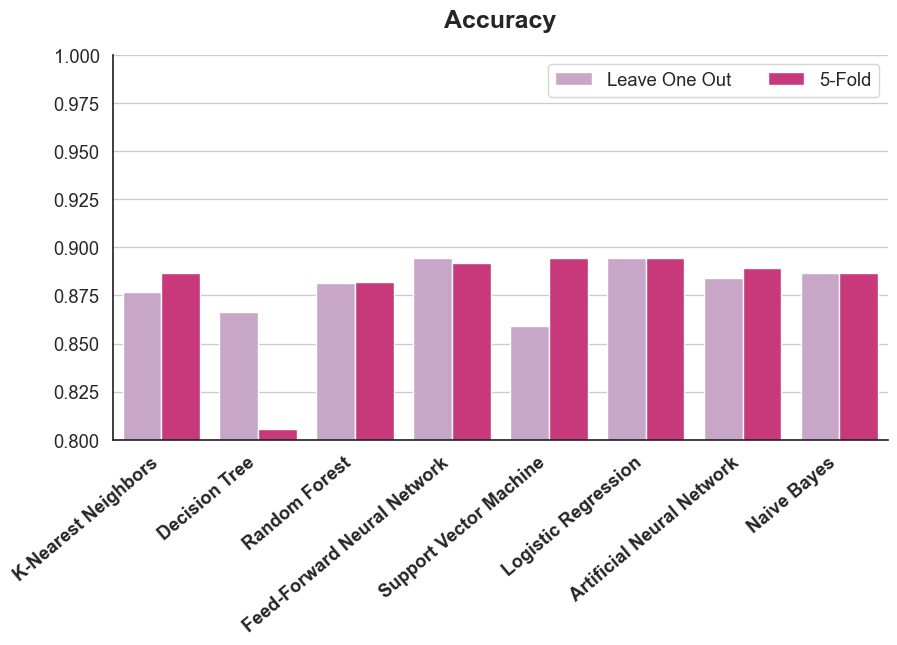

In [80]:
metric_bar_chart_by_cv(
    loocv_df,
    kfold_df,
    metric="Accuracy",
    title="Accuracy"
)

In [40]:
loocv_df

,Accuracy,F1 Score,AUC,MCC,Confusion Matrix
K-Nearest Neighbors,0.876574,0.880208,0.955381,0.813728,"[[103, 1, 0], [10, 105, 21], [0, 17, 140]]"
Decision Tree,0.866499,0.865803,0.922951,0.800918,"[[99, 4, 1], [12, 98, 26], [2, 8, 147]]"
Random Forest,0.881612,0.883499,0.954754,0.822586,"[[101, 3, 0], [8, 103, 25], [2, 9, 146]]"
Feed-Forward Neural Network,0.894207,0.895993,0.951011,0.841253,"[[103, 1, 0], [10, 106, 20], [0, 11, 146]]"
Support Vector Machine,0.858942,0.859057,0.918534,0.791006,"[[102, 1, 1], [12, 101, 23], [11, 8, 138]]"
Logistic Regression,0.894207,0.894974,0.932917,0.843293,"[[103, 1, 0], [10, 102, 24], [0, 7, 150]]"
Artificial Neural Network,0.884131,0.884829,0.955682,0.826241,"[[101, 3, 0], [11, 103, 22], [0, 10, 147]]"
Naive Bayes,0.886650,0.888409,0.942759,0.829749,"[[100, 4, 0], [8, 104, 24], [0, 9, 148]]"


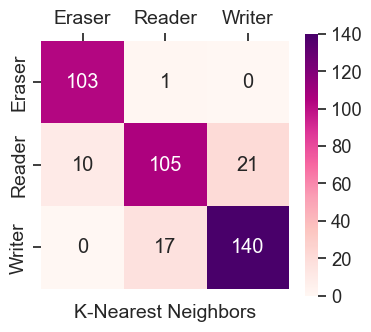

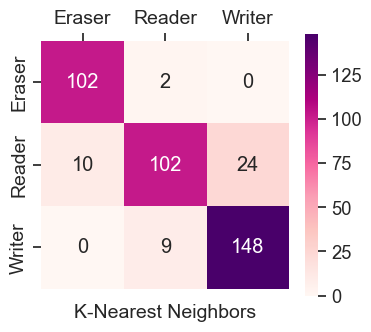

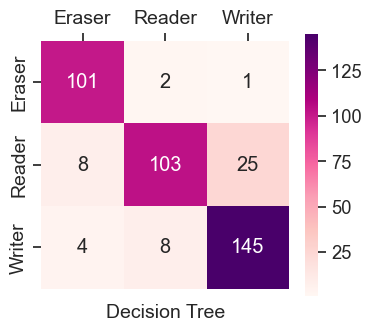

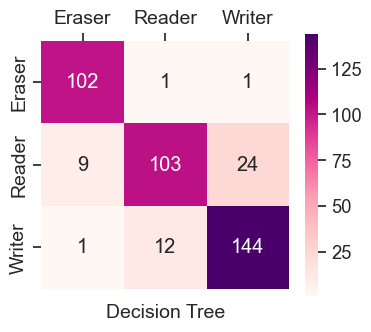

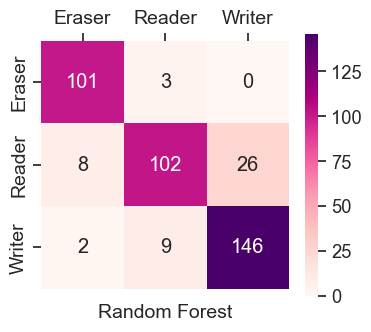

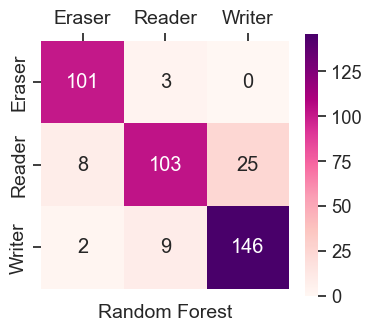

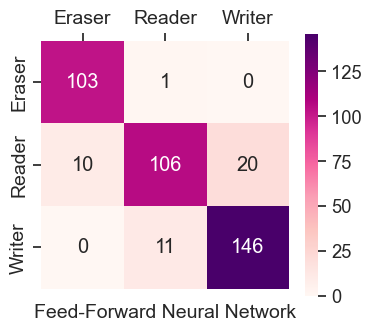

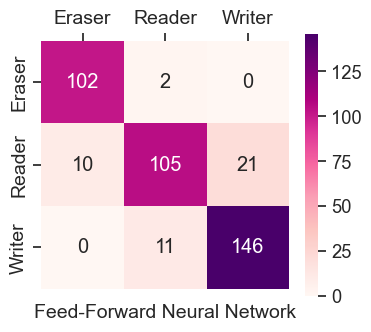

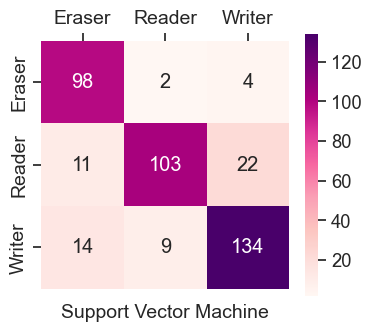

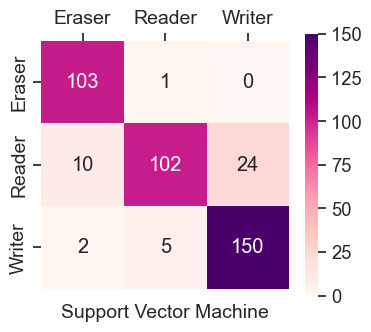

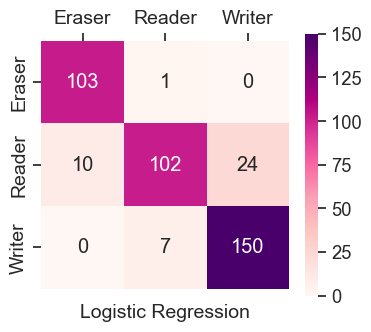

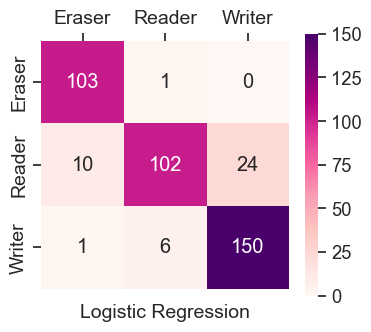

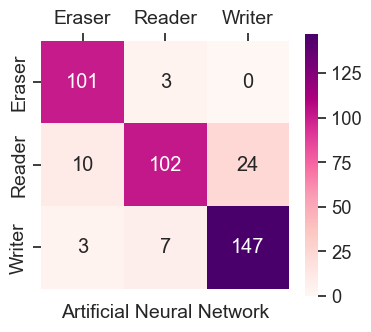

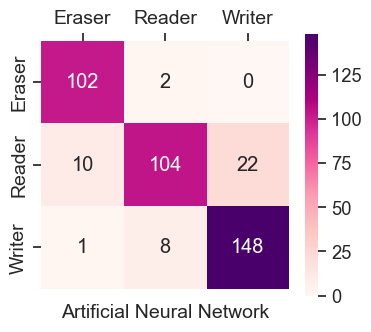

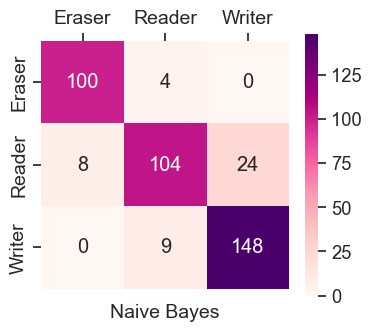

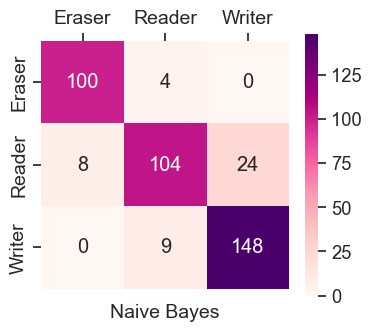

In [ ]:
for name, model in models.items():
    visualize_cm(
        loocv_df.loc[name, 'Confusion Matrix'],
        model_name=name,
        class_labels=class_labels,
    )
    visualize_cm(
        kfold_df.loc[name, 'Confusion Matrix'],
        model_name=name,
        class_labels=class_labels,
    )

In [24]:
loocv_df

,Accuracy,F1 Score,AUC,MCC,Confusion Matrix
K-Nearest Neighbors,0.876574,0.880208,0.955381,0.813728,"[[103, 1, 0], [10, 105, 21], [0, 17, 140]]"
Decision Tree,0.879093,0.880777,0.935882,0.819329,"[[101, 2, 1], [8, 103, 25], [4, 8, 145]]"
Random Forest,0.879093,0.881024,0.954459,0.818991,"[[101, 3, 0], [8, 102, 26], [2, 9, 146]]"
Feed-Forward Neural Network,0.894207,0.895993,0.950882,0.841253,"[[103, 1, 0], [10, 106, 20], [0, 11, 146]]"
Support Vector Machine,0.843829,0.844287,0.919173,0.766909,"[[98, 2, 4], [11, 103, 22], [14, 9, 134]]"
Logistic Regression,0.894207,0.894974,0.932917,0.843293,"[[103, 1, 0], [10, 102, 24], [0, 7, 150]]"
Artificial Neural Network,0.881612,0.881843,0.955445,0.823492,"[[101, 3, 0], [10, 102, 24], [3, 7, 147]]"
Naive Bayes,0.886650,0.888409,0.942759,0.829749,"[[100, 4, 0], [8, 104, 24], [0, 9, 148]]"


In [136]:
kfold_df

,Accuracy,F1 Score,AUC,MCC,Confusion Matrix,Model Name
K-Nearest Neighbors,0.886804,0.886672,0.946264,0.832460,"[[102, 2, 0], [10, 102, 24], [0, 9, 148]]",K-Nearest Neighbors
Decision Tree,0.879114,0.880958,0.935214,0.820452,"[[102, 1, 1], [9, 103, 24], [1, 12, 144]]",Decision Tree
Random Forest,0.881677,0.882824,0.962936,0.824120,"[[101, 3, 0], [8, 103, 25], [2, 9, 146]]",Random Forest
Feed-Forward Neural Network,0.889241,0.889892,0.962083,0.834858,"[[102, 2, 0], [10, 105, 21], [0, 11, 146]]",Feed-Forward Neural Network
Support Vector Machine,0.894335,0.893329,0.941517,0.845372,"[[103, 1, 0], [10, 102, 24], [2, 5, 150]]",Support Vector Machine
Logistic Regression,0.894335,0.893593,0.940408,0.845080,"[[103, 1, 0], [10, 102, 24], [1, 6, 150]]",Logistic Regression
Artificial Neural Network,0.891741,0.891377,0.962389,0.840195,"[[102, 2, 0], [10, 104, 22], [1, 8, 148]]",Artificial Neural Network
Naive Bayes,0.886772,0.887011,0.952216,0.831561,"[[100, 4, 0], [8, 104, 24], [0, 9, 148]]",Naive Bayes


<Axes: title={'center': '5-Fold'}>

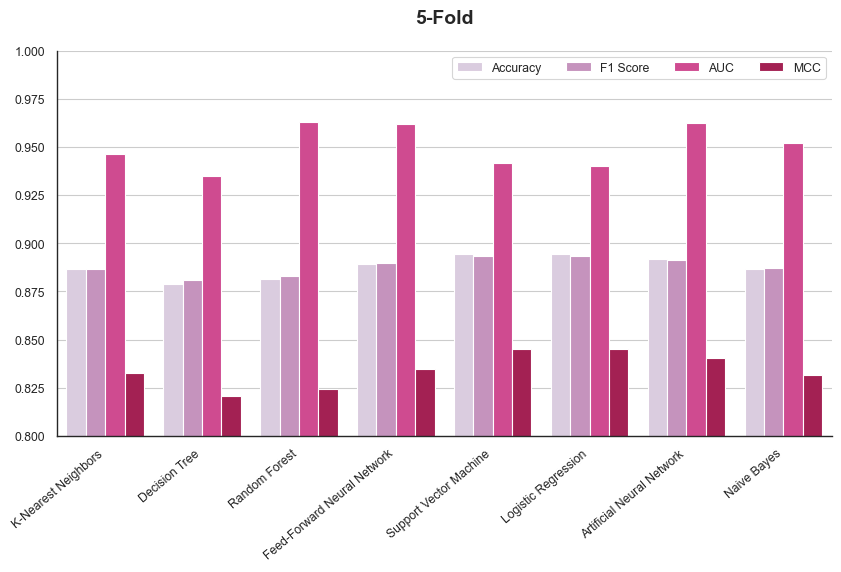

In [ ]:
all_metric_bar_chart(kfold_df, 0.8, 1, "5-Fold")

<Axes: title={'center': 'LOOCV'}>

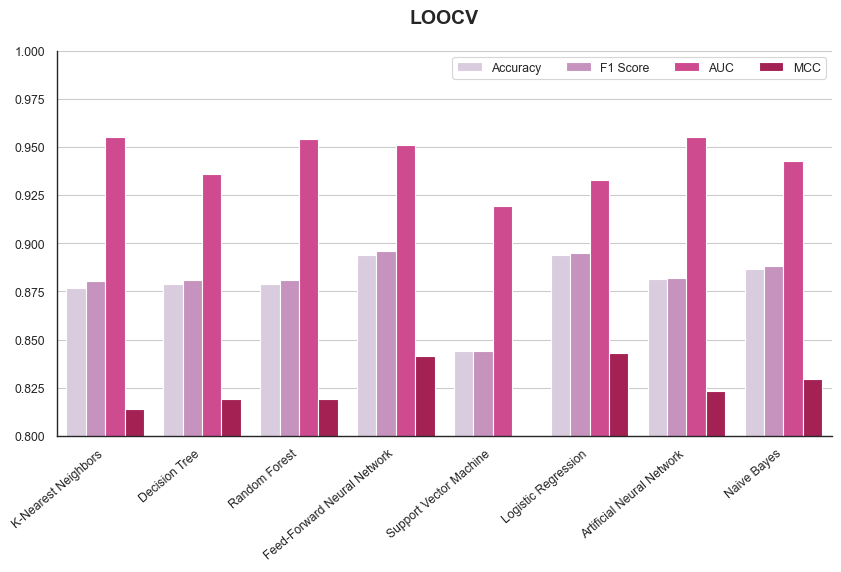

In [ ]:
all_metric_bar_chart(loocv_df, 0.8, 1, "LOOCV")